In [17]:
# Importing Libraries

import numpy as np
from matplotlib import pyplot 
from scipy.special import erf  

from GhostCells import Ghost_Cells

#Testing push for this file
# Testing rk push for this file


In [18]:
# Given Variables
Ma  = 0.2
Re  = 100

# Input Parameters

# x-direction variables 

Nx                  = 256               # Number of Nodes
x_start             = 0.0               # Physical start location
x_end               = 2*np.pi           # Physical end location

# y-direction variables

Ny                  = 256               # Number of Nodes
y_start             = 0.0               # Physical start location
y_end               = 2*np.pi           # Physical end location

# Other variables
             
order_of_derivative = 6                 # Derivative order
order_of_time       = 1                 # Time order
dim                 = 2                 # Two-Dimensional Space

# Fluid properties

R_u                 = 8.31446261815324  # Universal Gas Constant J/(mol * K)
m_air               = 28.97 / 1000      # Molar Mass of Air
gamma               = 7.0 / 5.0         # Standard Conditions of Air
R_s                 = R_u / m_air       # Specific gas contant for air
C_v                 = R_s / (gamma - 1.0)    
C_p                 = R_s + C_v           
Pr                  = 0.71


# Time varaibles

cfl                 = 0.1               # CFL number
t_end               = 0.1                 # End time
iter_end            = 100000            # Stop condition (may remove)

# Initial Conditions


p_0                 = 100000
T_0                 = 300
c_0                 = np.sqrt(gamma*R_s*T_0)
v_0                 = Ma * c_0
L                   = 2* np.pi
rho_0               = p_0 / (R_s * T_0)
mu                  = (rho_0 * v_0 * L) / Re
Sc                  =  1                 # Schmidt number
D                   = rho_0 / mu / Sc       # Diffusion coefficient
kappa               = mu * C_p / Pr
delta               = 1     
species             = 2    
print(D)   
print(mu) 

0.2292042392395836
5.067227577098024


In [19]:
# Parameters that can be calculated by input parameters

# Statment for Number of ghost cell required per boundary

if(order_of_derivative == 2):
    ngc = 1                     

elif(order_of_derivative == 4):
    ngc = 2  
    
elif(order_of_derivative == 6):
    ngc = 3

# x-direction parameters

dx      = (x_end - x_start) / (Nx)                                                   # Mesh Resolution
x       = np.linspace(x_start + dx/2 - ngc*dx, x_end - dx/2 + ngc*dx, Nx + 2*ngc)    # Generate array from 0 to 2pi with 100 nodes

# y-direction parameters

dy      = (y_end - y_start) / (Ny)                                                    # Mesh resolution
y       = np.linspace(y_start + dy/2 - ngc*dy, y_end - dy/2 + ngc*dy, Ny + 2*ngc)     # Generate array from 0 to 2pi with 100 nodes


V         = np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))                                       # density + 2 dimension of velocity + energy
Q         = np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))                                       # density + 2 dimension of momentum + energy
T         = np.zeros((Nx+2*ngc, Ny+2*ngc))                                              # May need to change
P         = np.zeros((Nx+2*ngc, Ny+2*ngc))
Y_2       = np.zeros((Nx+2*ngc, Ny+2*ngc,species))
J         = np.zeros((Nx+2*ngc, Ny+2*ngc,species))



rho_tot   = np.zeros((Nx+2*ngc, Ny+2*ngc))
# Mesh Generation

X,Y = np.meshgrid(x,y)


In [20]:
# Fill Ghost Cell function

def fill_gc_2D(V,ngc):
    V [:ngc,ngc:-ngc]     = V[-2*ngc:-ngc, ngc:-ngc]   # Fill the left ghost cell with the right data cell
    V [-ngc:,ngc:-ngc]    = V[ngc   :2*ngc,ngc:-ngc]   # Fill the right ghost cell with the left data cell
    V [ngc:-ngc,:ngc]     = V[ngc:-ngc, -2*ngc:-ngc]   # Fill the left ghost cell with the top data cell
    V [ngc:-ngc,-ngc:]    = V[ngc:-ngc, ngc  :2*ngc]   # Fill the right ghost cell with the bottom data cell
    
    # Fill corners
    V [-ngc:,-ngc:]     = V[ngc:2*ngc,ngc:2*ngc]        # Fill the right-top ghost cell
    V [:ngc,-ngc:]      = V[-2*ngc:-ngc,ngc:2*ngc]      # Fill the left-top ghost cell
    V [-ngc:,:ngc]      = V[ngc:2*ngc,-2*ngc:-ngc]      # Fill the right-bottom ghost cell
    V [:ngc,:ngc]       = V[-2*ngc:-ngc,-2*ngc:-ngc]    # Fill the left-bottom ghost cell

    return(V)

In [21]:
# Intial condtions set up
def initial_condition_TGV(Y_2,delta,V,v_0,p_0,rho_0,T_0,C_v,Nx,Ny,x,y,ngc,profile):
    for i in range(Nx):
        for j in range(Ny):
            width               = 2*np.pi
            if profile == 'square':
                bump_x              = 0.5 * (erf((x[i] - width / 4) / delta) - erf((x[i] - 3 * width / 4) / delta))
                bump_y              = 0.5 * (erf((y[j] - width / 4) / delta) - erf((y[j] - 3 * width / 4) / delta))
                Y_2[i+ngc, j+ngc, 0]          = bump_x * bump_y
                Y_2[i+ngc, j+ngc, 1]          = 1.0 - Y_2[i+ngc, j+ngc, 0]
            if profile == 'sinusoidal':
                Y_2[i, j, 0]          = (1+np.sin(x[i]))/2
                Y_2[i, j, 1]          = 1.0 - Y_2[i, j, 0]
            if profile == 'circle':
                cx = width / 2
                cy = width / 2
                r = np.sqrt((x[i+ngc] - cx)**2 + (y[j+ngc] - cy)**2)
                Y_2[i+ngc, j+ngc, 0] = 0.5 * (1 - erf((r - 1.0) / delta))
                Y_2[i+ngc, j+ngc, 1] = 1.0 - Y_2[i+ngc, j+ngc, 0]
                
            V[ngc+i, ngc+j, 0]  =  rho_0*Y_2[i+ngc, j+ngc, 0]
            V[ngc+i, ngc+j, 1]  =  rho_0*Y_2[i+ngc, j+ngc, 1]
            V[ngc+i, ngc+j, 2]  =  v_0*np.sin(x[ngc+i])*np.cos(y[ngc+j])
            V[ngc+i, ngc+j, 3]  = -v_0*np.cos(x[ngc+i])*np.sin(y[ngc+j])
            V[ngc+i, ngc+j, 4]  =  rho_0*(C_v*T_0 + 0.5*(V[ngc+i, ngc+j, 2]*V[ngc+i, ngc+j, 2] + V[ngc+i, ngc+j, 3]*V[ngc+i, ngc+j, 3]))
            P[ngc+i, ngc+j]     =  p_0 + (np.cos(2*x[ngc+i]) + np.cos(2*y[ngc+j]))*(rho_0/16.0)
            T[ngc+i, ngc+j]     =  T_0
            #rho_tot             =  V[ngc+i, ngc+j, 0] + V[ngc+i, ngc+j, 1] 
    return V, P, T, rho_tot,Y_2


In [22]:
# Variables from Ideal Gas Law
def pressure_from_ideal_gas_law(V,R_s,T,ngc):
    P[:,:]                                   = (V[:,:,0] + V[:,:,1])*R_s*T[:,:]
    return(P)


In [23]:
# Variables from internal Engergy

def calculate_T_from_e(e, C_v):
    T                    = e / C_v
    return(T)

In [24]:
# Time Step function

def time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T):
    u_mag     = np.sqrt(V[ngc:-ngc,ngc:-ngc,2]*V[ngc:-ngc,ngc:-ngc,2] + V[ngc:-ngc,ngc:-ngc,3]*V[ngc:-ngc,ngc:-ngc,3])
    c_0       = np.sqrt(gamma*R_s*T[ngc:-ngc,ngc:-ngc])
    u_mag    += c_0
    dt_adv    = min(cfl * dx / (np.max(np.amax(u_mag)) ), cfl * dy / np.max(np.amax(u_mag)))
    nu        = mu/(V[ngc:-ngc,ngc:-ngc,0] + V[ngc:-ngc,ngc:-ngc,1])
    dt_diff   = min(cfl * (dx*dx) / (np.max(np.amax(nu)) ), cfl * (dy*dy) / np.max(np.amax(nu)))
    dt        = min(dt_adv,dt_diff)
    return(dt)

In [25]:

def df_dx_2D(f, dx, order):
    """
    Compute the first derivative of f with respect to x
    
    Includes, 2nd, 4th, 6th order central scheme in this function
    
    Returns:
    df : array w/out ghost cells
        Derivative of f with respect to x, fluid domain plus ghost cells
    """
                    
    # determine number of ghost cells
    ngc = int(Ghost_Cells.number_ghost_cells(order))
    
    # Initialize array using np.zeros
    df_dx = np.zeros(np.shape(f))
    
    # Central difference 2nd order
    if order == 2:
        df_dx[ngc:-ngc, ngc:-ngc] = (
                + f[ngc+1:      , ngc:-ngc] 
                - f[ngc-1:-ngc-1, ngc:-ngc]
                ) / (2*dx)
    elif order == 4:
        df_dx[ngc:-ngc, ngc:-ngc] = (
                (
                -   f[ngc+2:      , ngc:-ngc] 
                + 8*f[ngc+1:-ngc+1, ngc:-ngc] 
                - 8*f[ngc-1:-ngc-1, ngc:-ngc] 
                +   f[ngc-2:-ngc-2, ngc:-ngc] 
                )
                / (12*dx)
        )
    elif order == 6:
        df_dx[ngc:-ngc, ngc:-ngc] = (
                (
                +    f[ngc+3:      , ngc:-ngc] 
                - 9 *f[ngc+2:-ngc+2, ngc:-ngc] 
                + 45*f[ngc+1:-ngc+1, ngc:-ngc] 
                - 45*f[ngc-1:-ngc-1, ngc:-ngc] 
                + 9 *f[ngc-2:-ngc-2, ngc:-ngc] 
                -    f[ngc-3:-ngc-3, ngc:-ngc] 
                )
                / (60*dx)
        )
        
    # Fill ghost cells here
    df_dx = Ghost_Cells.fill_ghost_cells_2D_single(df_dx, order)
            
    return df_dx
    

def df_dy_2D(f, dy, order):
    """
    Compute the first derivative of f with respect to y
    
    Inlcudes, 2nd, 4th, 6th order central scheme in this function
    
    Returns:
    df : array w/out ghost cells
        Derivative of f with respect to y, fluid domain plus ghost cells
    """
                    
    # determine number of ghost cells
    ngc = int(Ghost_Cells.number_ghost_cells(order))
    
    # Initalize array
    df_dy = np.zeros(np.shape(f))
    
    # Central difference 2nd order
    if order == 2:
        df_dy[ngc:-ngc, ngc:-ngc] = (
            (
                f[ngc:-ngc, ngc+1:      ] 
            +   f[ngc:-ngc, ngc-1:-ngc-1]
            ) 
            / (2*dy)            
        )
    elif order == 4:
        df_dy[ngc:-ngc, ngc:-ngc] = (
            (
            -   f[ngc:-ngc, ngc+2:      ] 
            + 8*f[ngc:-ngc, ngc+1:-ngc+1] 
            - 8*f[ngc:-ngc, ngc-1:-ngc-1] 
            +   f[ngc:-ngc, ngc-2:-ngc-2] 
            )
            / (12*dy)
        )
    elif order == 6:
        df_dy[ngc:-ngc, ngc:-ngc] = (
            (
            +    f[ngc:-ngc, ngc+3:      ] 
            - 9 *f[ngc:-ngc, ngc+2:-ngc+2] 
            + 45*f[ngc:-ngc, ngc+1:-ngc+1] 
            - 45*f[ngc:-ngc, ngc-1:-ngc-1] 
            + 9 *f[ngc:-ngc, ngc-2:-ngc-2] 
            -    f[ngc:-ngc, ngc-3:-ngc-3] 
            )
            / (60*dy)
        )
        
    # Fill gc here
    df_dy = Ghost_Cells.fill_ghost_cells_2D_single(df_dy, order)    
    return df_dy


def d2f_dx2_2D(f, dx, order):
    """
    Compute the second derivative of f with respect to x    
    
    Inlcudes, 2nd, 4th, 6th order central scheme in this function  
    
    Returns:
    d2f_dx2 : array with ghost cells     
    
    """

    #determine number of ghost cells
    ngc = int(Ghost_Cells.number_ghost_cells(order))
    
    # Initalize array
    d2f_dx2   = np.zeros(np.shape(f))
    
    # Central difference 2nd order
    if order == 2:
        d2f_dx2[ngc:-ngc, ngc:-ngc] = (
            (
                +   f[ngc+1:      , ngc:-ngc] 
                - 2*f[ngc  :-ngc  , ngc:-ngc] 
                +   f[ngc-1:-ngc-1, ngc:-ngc]
            ) 
            / (dx**2)
        )
    elif order == 4:
        d2f_dx2[ngc:-ngc, ngc:-ngc] = (
            (
                -    f[ngc+2:      , ngc:-ngc] 
                + 16*f[ngc+1:-ngc+1, ngc:-ngc] 
                - 30*f[ngc  :-ngc  , ngc:-ngc] 
                + 16*f[ngc-1:-ngc-1, ngc:-ngc] 
                -    f[ngc-2:-ngc-2, ngc:-ngc]
            ) 
            / (12*dx**2)
        )
    elif order == 6:
        d2f_dx2[ngc:-ngc, ngc:-ngc] = (
            (
                + (1/90) * f[ngc+3:      , ngc:-ngc] 
                - (3/20) * f[ngc+2:-ngc+2, ngc:-ngc] 
                + (3/2)  * f[ngc+1:-ngc+1, ngc:-ngc] 
                - (49/18)* f[ngc  :-ngc  , ngc:-ngc] 
                + (3/2)  * f[ngc-1:-ngc-1, ngc:-ngc] 
                - (3/20) * f[ngc-2:-ngc-2, ngc:-ngc] 
                + (1/90) * f[ngc-3:-ngc-3, ngc:-ngc]
            ) 
            / (dx**2)
        )
        
    # Fill gc here
    d2f_dx2 = Ghost_Cells.fill_ghost_cells_2D_single(d2f_dx2, order)
        
    return d2f_dx2

def d2f_dy2_2D(f, dy, order):
    """
    Compute the second derivative of f with respect to y
    
    Inlcudes, 2nd, 4th, 6th order central scheme in this function
    
    Returns:
    d2f_dy2 : array with ghost cells
    """
    
    #determine number of ghost cells
    ngc = int(Ghost_Cells.number_ghost_cells(order))

    # Initalize array
    d2f_dy2   = np.zeros(np.shape(f))
    
    # Central difference 2nd order
    if order == 2:
        d2f_dy2[ngc:-ngc, ngc:-ngc] = (
            (
                    f[ngc:-ngc, ngc+1:      ] 
                - 2*f[ngc:-ngc, ngc  :-ngc  ] 
                +   f[ngc:-ngc, ngc-1:-ngc-1]
            ) 
            / (dy**2)
        )
    elif order == 4:
        d2f_dy2[ngc:-ngc, ngc:-ngc] = (
            (
                -    f[ngc:-ngc, ngc+2:      ] 
                + 16*f[ngc:-ngc, ngc+1:-ngc+1] 
                - 30*f[ngc:-ngc, ngc  :-ngc  ] 
                + 16*f[ngc:-ngc, ngc-1:-ngc-1] 
                -    f[ngc:-ngc, ngc-2:-ngc-2]
            ) 
            / (12*dy**2)
        )
    elif order == 6:
        d2f_dy2[ngc:-ngc, ngc:-ngc] = (
            (
                + (1/90) * f[ngc:-ngc, ngc+3:      ] 
                - (3/20) * f[ngc:-ngc, ngc+2:-ngc+2] 
                + (3/2)  * f[ngc:-ngc, ngc+1:-ngc+1] 
                - (49/18)* f[ngc:-ngc, ngc  :-ngc  ] 
                + (3/2)  * f[ngc:-ngc, ngc-1:-ngc-1] 
                - (3/20) * f[ngc:-ngc, ngc-2:-ngc-2] 
                + (1/90) * f[ngc:-ngc, ngc-3:-ngc-3]
            ) 
            / (dy**2)
        )
        
    # Fill gc here
    d2f_dy2 = Ghost_Cells.fill_ghost_cells_2D_single(d2f_dy2, order)
    
    return d2f_dy2


In [26]:
# Calculating Tau's
def calculate_tau(u,v,dx,dy,mu, order_of_derivative):
    ngc = int(Ghost_Cells.number_ghost_cells(order_of_derivative))
    
    tau_xx = (2.0/3.0)*mu*(2*df_dx_2D(u, dx, order_of_derivative) - df_dy_2D(v,dy, order_of_derivative))
    tau_yy = (2.0/3.0)*mu*(2*df_dy_2D(v,dy,order_of_derivative) - df_dx_2D(u,dx, order_of_derivative))
    tau_xy = mu*(df_dy_2D(u,dy,order_of_derivative) + df_dx_2D(v,dx, order_of_derivative))

    tau_xx = fill_gc_2D(tau_xx,ngc)
    tau_yy = fill_gc_2D(tau_yy,ngc)
    tau_xy = fill_gc_2D(tau_xy,ngc)
    return(tau_xx,tau_yy,tau_xy)


def get_Q_from_V(V,Q):
    Q[:,:,0] = V[:,:,0]                         #rho*Y[0]   
    Q[:,:,1] = V[:,:,1]                         #rho*Y[1]
    Q[:,:,2] = (V[:,:,0]+V[:,:,1])*V[:,:,2]     #rho*u
    Q[:,:,3] = (V[:,:,0]+V[:,:,1])*V[:,:,3]     #rho*v
    Q[:,:,4] = V[:,:,4] * (V[:,:,0] + V[:,:,1])   #Energy
    return(Q)

def get_V_from_Q(Q,V):
    V[:,:,0] = Q[:,:,0]                         #rho*Y[0] 
    V[:,:,1] = Q[:,:,1]                         #rho*Y[1]                    
    V[:,:,2] = Q[:,:,2]/(Q[:,:,0]+Q[:,:,1])     # u
    V[:,:,3] = Q[:,:,3]/(Q[:,:,0]+Q[:,:,1])     # v
    V[:,:,4] = Q[:,:,4]                         # Energy        
    return(V)

In [27]:
def get_Convective_flux(V, P, order):
    #Convective fluxes, already derivatives taken
    ngc = int(Ghost_Cells.number_ghost_cells(order))

    Cx =    np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))  # Convective flux in x-direction
    Cy =    np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))  # Convective flux in y-direction
   
    # Cx[0] = rho*u * Y[0]
    # Cx[1] = rho*u*Y[1]
    # Cx[2] = rho*u^2 + P
    # Cx[3] = rho*u*v
    # Cx[4] = E*u
    Cx[:,:,0] = df_dx_2D(V[:,:,0]*V[:,:,2], dx, order)
    Cx[:,:,1] = df_dx_2D(V[:,:,1]*V[:,:,2], dx, order)
    Cx[:,:,2] = df_dx_2D((V[:,:,0]+V[:,:,1])*V[:,:,2]*V[:,:,2] + P[:,:], dx, order)
    Cx[:,:,3] = df_dx_2D(V[:,:,2]*(V[:,:,1]+V[:,:,0])* V[:,:,3], dx, order)
    Cx[:,:,4] = df_dx_2D((V[:,:,4] * (V[:,:,0] + V[:,:,1]) + P[:,:])* V[:,:,2], dx, order)

    # Cy[0] = rho*v * Y[0]
    # Cy[1] = rho*u*v
    # Cy[2] = rho*v^2 + P
    # Cy[3] = E*v
    # Cy[4] = rho*v*Y[1]
    Cy[:,:,0] = df_dy_2D(V[:,:,0]*V[:,:,3], dy, order)
    Cy[:,:,1] = df_dy_2D(V[:,:,1]*V[:,:,3], dy, order)
    Cy[:,:,2] = df_dy_2D((V[:,:,0]+V[:,:,1])*V[:,:,2]*V[:,:,2] + P[:,:], dy, order)
    Cy[:,:,3] = df_dy_2D((V[:,:,0]+V[:,:,1])*V[:,:,3]*V[:,:,3] + P[:,:], dy, order)
    Cy[:,:,4] = df_dy_2D((V[:,:,4] * (V[:,:,0] + V[:,:,1]) + P[:,:]) * V[:,:,3], dy, order)

    # Fill ghost cells
    Cx = Ghost_Cells.fill_ghost_cells_2D_single(Cx, order)
    Cy = Ghost_Cells.fill_ghost_cells_2D_single(Cy, order)

    return Cx, Cy

In [28]:
def get_Diffusive_flux(V, D, T, kappa, dx, dy, mu, order):
    # Diffusive fluxes, already derivatives taken
    ngc = int(Ghost_Cells.number_ghost_cells(order))

    Dx =    np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))  # Diffusive flux in x-direction
    Dy =    np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))  # Diffusive flux in y-direction
    # Calculate Tau's
    tau_xx, tau_yy, tau_xy = calculate_tau(V[:,:,2], V[:,:,3], dx, dy, mu, order)

    # Dx[0] = rho * D * d2Y[0]_dx2
    # Dx[1] = rho * D * d2Y[1]_dx2
    # Dx[2] = df_dx(tau_xx)
    # Dx[3] = df_dx(tau_xy)
    # Dx[4] = df_dx(tau_xx*u + tau_xy*v + kappa*dT/dx) + C_p*D*d2f_dx2(T*rho*Y[0] + T*rho*Y[1]) + 2 * C_p*D*d2f_dxdy(T*rho*Y[0])
    Dx[:,:,0] = (V[:,:,0] +V[:,:,1])* D * d2f_dx2_2D(V[:,:,0]/(V[:,:,0] +V[:,:,1]), dx, order)
    Dx[:,:,1] = (V[:,:,0] +V[:,:,1])* D * d2f_dx2_2D(V[:,:,1]/(V[:,:,0] +V[:,:,1]), dx, order)
    Dx[:,:,2] = df_dx_2D(tau_xx, dx, order)
    Dx[:,:,3] = df_dx_2D(tau_xy, dx, order)
    Dx[:,:,4] = df_dx_2D(tau_xx*V[:,:,2] + tau_xy*V[:,:,3], dx, order) \
                + d2f_dx2_2D(kappa*T[:,:], dx, order) \
                + C_p*D*(d2f_dx2_2D(T[:,:]*(V[:,:,0] + V[:,:,1]), dx, order)\
                        + 2*df_dx_2D(df_dy_2D(T[:,:] * V[:,:,0],dy,order),dx,order))
 
    # Dy[0] = rho * D * d2Y[0]_dy2
    # Dy[1] = rho * D * d2Y[1]_dy2
    # Dy[2] = df_dy(tau_xy)
    # Dy[3] = df_dy(tau_yy)
    # Dy[4] = df_dy(tau_xy*u + tau_yy*v + kappa*dT/dy) + C_p*D*d2f_dy2(T*rho*Y[0] + T*rho*Y[1]) + 2 * C_p*D*d2f_dxdy(T*rho*Y[1])
    Dy[:,:,0] = (V[:,:,0] +V[:,:,1])* D * d2f_dy2_2D(V[:,:,0]/(V[:,:,0] +V[:,:,1]), dy, order)
    Dy[:,:,1] = (V[:,:,0] +V[:,:,1])* D * d2f_dy2_2D(V[:,:,1]/(V[:,:,0] +V[:,:,1]), dy, order)
    Dy[:,:,2] = df_dy_2D(tau_xy, dy, order)
    Dy[:,:,3] = df_dy_2D(tau_yy, dy, order)
    Dy[:,:,4] = df_dy_2D(tau_xy*V[:,:,2] + tau_yy*V[:,:,3], dy, order) \
                + d2f_dy2_2D(kappa*T[:,:], dy, order) \
                + C_p*D*(d2f_dy2_2D(T[:,:]*(V[:,:,0] + V[:,:,1]), dy, order)\
                        + 2*df_dy_2D(df_dx_2D(T[:,:] * V[:,:,1],dx,order),dy,order))
    
    # Fill ghost cells
    Dx = Ghost_Cells.fill_ghost_cells_2D_single(Dx, order)
    Dy = Ghost_Cells.fill_ghost_cells_2D_single(Dy, order)

    return Dx, Dy

In [29]:
def get_fluxes(V, P, T, D, kappa, dx, dy, order):
    # No time here, just fluxes
    Q    = np.zeros((Nx+2*ngc, Ny+2*ngc, dim+3))  # density + 2 dimension of momentum + energy

    e    = (V[:,:,4] / (V[:,:,0] + V[:,:,1])   - 0.5 * (V[:,:,2] * V[:,:,2] + V[:,:,3] * V[:,:,3])) 
    #e    = P / ((gamma-1)*(V[:,:,0]+V[:,:,1]))
    
    T    = calculate_T_from_e(e, C_v)
    T[:,:] = fill_gc_2D(T[:,:],ngc)
    P    = pressure_from_ideal_gas_law(V,R_s,T[:,:],ngc)
    P[:,:] = fill_gc_2D(P[:,:],ngc)
    

    Cx, Cy = get_Convective_flux(V, P, order)
    Dx, Dy = get_Diffusive_flux(V, D, T, kappa, dx, dy, mu, order)

    Q[:,:,:] = (- Cx[:,:,:] - Cy[:,:,:]) + Dx[:,:,:] + Dy[:,:,:]   

    # Fill ghost cells
    Q[:,:,:] = Ghost_Cells.fill_ghost_cells_2D(Q, order)

    return Q

current_time: 0.0


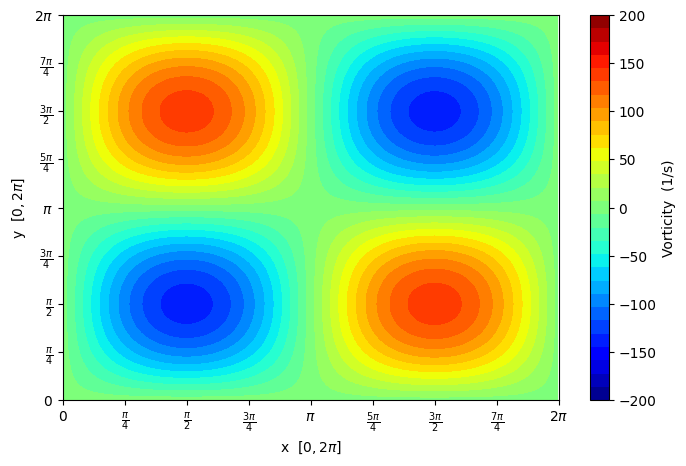

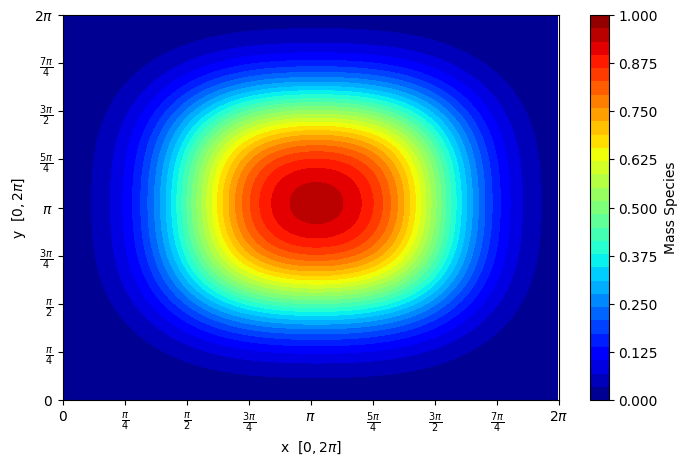

C:\Users\ryann\AppData\Local\Temp\ipykernel_14480\3353839124.py:5: RuntimeWarning: invalid value encountered in sqrt
  c_0       = np.sqrt(gamma*R_s*T[ngc:-ngc,ngc:-ngc])


In [30]:
# Main code for New RK stuff
V,P,T,rho_total,Y_2 = initial_condition_TGV(Y_2,delta,V,v_0,p_0,rho_0,T_0,C_v,Nx,Ny,x,y,ngc,profile='square')

# Fill ghost cells on intial conditions
V[:,:,0] = fill_gc_2D(V[:,:,0],ngc)         # Density
V[:,:,1] = fill_gc_2D(V[:,:,1],ngc)         # x-direction Velocity
V[:,:,2] = fill_gc_2D(V[:,:,2],ngc)         # y-direction Velocity
V[:,:,3] = fill_gc_2D(V[:,:,3],ngc)         # Energy
V[:,:,4] = fill_gc_2D(V[:,:,4],ngc)         # Energy
P        = fill_gc_2D(P[:,:],ngc)           # Pressure
T        = fill_gc_2D(T[:,:],ngc)           # Temperature
rho_tot  = fill_gc_2D(rho_tot[:,:],ngc)     # Total Density
Y_2      = fill_gc_2D(Y_2[:,:],ngc)         # Y

# Create initial time step
dt   = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T)

# Initalization

#import time
current_time                = 0.0
iter                        = 0
flag                        = False

# Plot Times

plot_times                  = [0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1] # 0.01 is the first plot time  
next_plot_time              = plot_times.pop(0)
t                           = []
ke                          = []
enstrophy                   = []  
ke2                         = []


while(current_time < t_end):    
    if((current_time+dt) > next_plot_time):                 # Statement to make sure that the plot time is the same as the current time
        dt                  = next_plot_time - current_time
        flag                = True                               
    # Time counter
    t.append(current_time)   
    
    Q = get_Q_from_V(V,Q) 

    # RK1
    if order_of_time == 1:

        e    = (V[:,:,4] / (V[:,:,0] + V[:,:,1])   - 0.5 * (V[:,:,2] * V[:,:,2] + V[:,:,3] * V[:,:,3])) 
        
        T    = calculate_T_from_e(e, C_v)
        T[:,:] = fill_gc_2D(T[:,:],ngc)

        P    = pressure_from_ideal_gas_law(V,R_s,T[:,:],ngc)
        P[:,:] = fill_gc_2D(P[:,:],ngc)
            
        # Get fluxes
        Q += dt*get_fluxes(V, P, T, D, kappa, dx, dy, order_of_derivative)

        V = get_V_from_Q(Q,V)




    elif order_of_time == 2:
       
        Q1 += dt*get_fluxes(V, P, T, D, kappa, dx, dy, order_of_derivative)
        
        V = get_V_from_Q(Q1, V)

        # Fill gc
        V[:,:,0] = fill_gc_2D(V[:,:,0],ngc)         
        V[:,:,1] = fill_gc_2D(V[:,:,1],ngc)          
        V[:,:,2] = fill_gc_2D(V[:,:,2],ngc)
        V[:,:,3] = fill_gc_2D(V[:,:,3],ngc)
        V[:,:,4] = fill_gc_2D(V[:,:,4],ngc)

        Q2 += dt*get_fluxes(V, P, T, D, kappa, dx, dy, order_of_derivative)







    # # Kinetic Energy using Velocity
    kinetic2  = (np.mean((V[ngc:-ngc,ngc:-ngc,1]+V[ngc:-ngc,ngc:-ngc,0])* 0.5 * (V[ngc:-ngc,ngc:-ngc,2] * V[ngc:-ngc,ngc:-ngc,2] + V[ngc:-ngc,ngc:-ngc,3] * V[ngc:-ngc,ngc:-ngc,3])))
    ke2.append(kinetic2)
     
   
    if (np.max(Q[:,:,0]/(V[:,:,0] + V[:,:,1])) > 1.0):
        print(np.max(Q[:,:,0]/( V[:,:,0] + V[:,:,1])))
    elif (np.max(Q[:,:,1]/( V[:,:,0] + V[:,:,1])) > 1.0):
        print(np.max(Q[:,:,1]/(V[:,:,0] + V[:,:,1])))

    
    current_time            += dt
    dt                      = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T) 
    
    
    iter        += 1
    
    if (flag == True):          #Statement to plot when the current _time == next_plot_time
        X,Y = np.meshgrid(x,y)
        print(f'current_time: {current_time}')
        pyplot.figure(figsize=(8,5))
        # vorticity           = df_dy_second_order_centered_2D(V[:,:,2],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,3],dx,ngc)[ngc:-ngc,ngc:-ngc]
        vorticity           = df_dy_2D(V[:,:,2],dy,order_of_derivative)[ngc:-ngc,ngc:-ngc] - df_dx_2D(V[:,:,3],dx,order_of_derivative)[ngc:-ngc,ngc:-ngc]
        contour             = pyplot.contourf(X[ngc:-ngc,ngc:-ngc], Y[ngc:-ngc,ngc:-ngc],  vorticity, cmap = "jet",levels=np.linspace(-200,200,30)) # Used Chatgpt for levels
        cbar                = pyplot.colorbar(contour)
        cbar.set_ticks(np.linspace(-200,200,9))  # Used Chatgpt for colorbar ticks
        cbar.set_label("Vorticity  (1/s)") 
        pyplot.xlim(0,2*np.pi)
        pyplot.xticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
                  r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
        pyplot.ylim(0,2*np.pi)
        pyplot.yticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
                  r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
        pyplot.xlabel(r"x  [$0, 2\pi$]")
        pyplot.ylabel(r"y  [$0, 2\pi$]")
        pyplot.show()
        pyplot.figure(figsize=(8,5))
        contour             = pyplot.contourf(X[ngc:-ngc,ngc:-ngc], Y[ngc:-ngc,ngc:-ngc],  Q[ngc:-ngc,ngc:-ngc,0]/(Q[ngc:-ngc,ngc:-ngc,1] + Q[ngc:-ngc,ngc:-ngc,0]), cmap = "jet",levels=np.linspace(0,1,30)) # Used Chatgpt for levels
        cbar                = pyplot.colorbar(contour) # Used Chatgpt for colorbar
        cbar.set_ticks(np.linspace(0,1,9))  # Used Chatgpt for colorbar ticks
        cbar.set_label("Mass Species")        # Used Chatgpt for colorbar label
        pyplot.xlim(0,2*np.pi)
        pyplot.xticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
                  r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
        pyplot.ylim(0,2*np.pi)
        pyplot.yticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
                  r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
        pyplot.xlabel(r"x  [$0, 2\pi$]")
        pyplot.ylabel(r"y  [$0, 2\pi$]")
        pyplot.show()
        if plot_times:  #Statement to change next_plot_time and reset flag 
            next_plot_time  = plot_times.pop(0)                                
            flag            = False
        if next_plot_time == t_end and flag == True:
            pyplot.figure(figsize=(8,5))
            pyplot.plot(t, ke2) # Used Chatgpt for levels
            pyplot.xlabel("Time (s)")
            pyplot.ylabel("Average Kinetic Energy (kg/(m*s$^2$))")
            pyplot.show()
            # pyplot.figure(figsize=(8,5))
            # pyplot.plot(t, ke2) # Used Chatgpt for levels
            # pyplot.xlabel("Time (s)")
            # pyplot.ylabel("Average Kinetic Energy (kg/(m*s$^2$))")
            # pyplot.show()
            # pyplot.figure(figsize=(8,5))
            # pyplot.plot(t, enstrophy) # Used Chatgpt for levels
            # pyplot.xlabel("Time (s)")
            # pyplot.ylabel("Average Enstrophy (m$^2$/s$^2$)")
            # pyplot.show()
            break


In [31]:
# # Main code
    
# V,P,T,rho_total,Y_2 = initial_condition_TGV(Y_2,delta,V,v_0,p_0,rho_0,T_0,C_v,Nx,Ny,x,y,ngc,profile='circle')
# #print(rho_total)
# # Fill ghost cells on intial conditions
# V[:,:,0] = fill_gc_2D(V[:,:,0],ngc)         # Density
# V[:,:,1] = fill_gc_2D(V[:,:,1],ngc)         # x-direction Velocity
# V[:,:,2] = fill_gc_2D(V[:,:,2],ngc)         # y-direction Velocity
# V[:,:,3] = fill_gc_2D(V[:,:,3],ngc)         # Energy
# V[:,:,4] = fill_gc_2D(V[:,:,4],ngc)         # Energy
# P        = fill_gc_2D(P[:,:],ngc)           # Pressure
# T        = fill_gc_2D(T[:,:],ngc)           # Temperature
# rho_tot  = fill_gc_2D(rho_tot[:,:],ngc)     # Total Density
# Y_2      = fill_gc_2D(Y_2[:,:],ngc)         # Y
# #print(V[:,:,0])
# Q        = get_Q_from_V(V,Q)

# # Create initial time step
# dt   = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T)

# # Initalization

# #import time
# current_time                = 0.0
# iter                        = 0
# flag                        = False

# # Plot Times

# plot_times                  = [0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1] # 0.01 is the first plot time  
# next_plot_time              = plot_times.pop(0)
# t                           = []
# ke                          = []
# enstrophy                   = []  
# ke2                         = []
# while(current_time < t_end):    
#     if((current_time+dt) > next_plot_time):                 # Statement to make sure that the plot time is the same as the current time
#         dt                  = next_plot_time - current_time
#         flag                = True                               
#     # Time counter
#     t.append(current_time)   
   
#     #Top one worked
#     e    = (V[:,:,4] / (V[:,:,0] + V[:,:,1])   - 0.5 * (V[:,:,2] * V[:,:,2] + V[:,:,3] * V[:,:,3])) 
#     #e    = P / ((gamma-1)*(V[:,:,0]+V[:,:,1]))
#     #print(e)
#     T    = calculate_T_from_e(e, C_v)
#     T[:,:] = fill_gc_2D(T[:,:],ngc)
#     P    = pressure_from_ideal_gas_law(V,R_s,T[:,:],ngc)
#     P[:,:] = fill_gc_2D(P[:,:],ngc)
#     #print(e)
#     #print(T)
#     #print(P)
#     # Enstrophy
#     #enstrophy.append(np.mean((df_dy_second_order_centered_2D(V[:,:,1],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,2],dx,ngc)[ngc:-ngc,ngc:-ngc]) * (df_dy_second_order_centered_2D(V[:,:,1],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,2],dx,ngc)[ngc:-ngc,ngc:-ngc])))
#     # Calculate P and T
#     # Kinetic Energy using E
#     # Both Match

#     #kinetic  = (np.mean(V[ngc:-ngc,ngc:-ngc,3] - V[ngc:-ngc,ngc:-ngc,0] * e[ngc:-ngc,ngc:-ngc] ))
#     # kinetic  = (np.mean(V[ngc:-ngc,ngc:-ngc,3] - V[ngc:-ngc,ngc:-ngc,0] * C_v*T[ngc:-ngc,ngc:-ngc] ))
#     # ke.append(kinetic)

#     # # Kinetic Energy using Velocity
#     kinetic2  = (np.mean((V[ngc:-ngc,ngc:-ngc,1]+V[ngc:-ngc,ngc:-ngc,0])* 0.5 * (V[ngc:-ngc,ngc:-ngc,2] * V[ngc:-ngc,ngc:-ngc,2] + V[ngc:-ngc,ngc:-ngc,3] * V[ngc:-ngc,ngc:-ngc,3])))
#     ke2.append(kinetic2)

#     # Calculate Tau's
#     tau_xx, tau_yy, tau_xy = calculate_tau(V[:,:,2],V[:,:,3],dx,dy,mu, order_of_derivative)

   
#     rho    = (Q[:,:,1] + Q[:,:,0])
   
#     # Q[0]    =   (- df_dx(rho*u*Y[0]) - df_dy(rho*v*Y[0]) + D *rho* d2f_dx2(rho*Y[0]) + D *rho* d2f_dy2(Y[0]))*dt
    
#     Q[:,:,0] += (-df_dx_2D(V[:,:,2]*Q[:,:,0],dx, order_of_derivative) - df_dy_2D(V[:,:,3]*Q[:,:,0],dy,order_of_derivative) 
#                  + rho*D * d2f_dx2_2D(Q[:,:,0]/(rho),dx,order_of_derivative) 
#                  + rho*D * d2f_dy2_2D(Q[:,:,0]/(rho),dy,order_of_derivative))*dt

#     # Q[1]    =   (- df_dx(rho*u*Y[1]) - df_dy(rho*v*Y[1]) + D *rho* d2f_dx2(rho*Y[1]) + D * rho*d2f_dy2(Y[1]))*dt
   
#     Q[:,:,1] += (-df_dx_2D(V[:,:,2]*Q[:,:,1],dx,order_of_derivative) - df_dy_2D(V[:,:,3]*Q[:,:,1],dy,order_of_derivative) 
#                  + rho*D * d2f_dx2_2D(Q[:,:,1]/(rho),dx,order_of_derivative) 
#                  + rho*D * d2f_dy2_2D(Q[:,:,1]/(rho),dy,order_of_derivative))*dt
    
#     # Q[:,:,2] += (-(df_dx_second_order_centered_2D(Q[:,:,2] * V[:,:,2] + P[:,:],dx,ngc) 
    
#     Q[:,:,2] += (-(df_dx_2D(Q[:,:,2] * V[:,:,2] + P[:,:],dx, order_of_derivative) 
#                    + df_dy_2D(Q[:,:,2] * V[:,:,3],dy,order_of_derivative)) + 
#                    df_dx_2D(tau_xx,dx,order_of_derivative) + df_dy_2D(tau_xy,dy,order_of_derivative))*dt
    
#     # Q[:,:,3] += (-(df_dx_second_order_centered_2D( V[:,:,2]*(V[:,:,1]+V[:,:,0])* V[:,:,3],dx,ngc) # I am worried about using q[2] since we just updated it V[:,:,2]*(V[:,:,1]+V[:,:,0])
   
#     Q[:,:,3] += (-(df_dx_2D( V[:,:,2]*(V[:,:,1]+V[:,:,0])* V[:,:,3],dx,order_of_derivative) # I am worried about using q[2] since we just updated it V[:,:,2]*(V[:,:,1]+V[:,:,0])
#                 + df_dy_2D(Q[:,:,3] * V[:,:,3] + P[:,:],dy,order_of_derivative)) 
#                 + df_dx_2D(tau_xy,dx,order_of_derivative) + df_dy_2D(tau_yy,dy,order_of_derivative))*dt
  

#     Q[:,:,4] += (-df_dx_2D((Q[:,:,4] + P[:,:]) * V[:,:,2],dx,order_of_derivative) - df_dy_2D((Q[:,:,4] + P[:,:]) * V[:,:,3],dy,order_of_derivative)
#     + df_dx_2D(tau_xx * V[:,:,2] + tau_xy * V[:,:,3] + kappa * df_dx_2D(T[:,:],dx,order_of_derivative),dx,order_of_derivative) 
#     + df_dy_2D(tau_xy * V[:,:,2] + tau_yy * V[:,:,3] + kappa * df_dy_2D(T[:,:],dy,order_of_derivative),dy,order_of_derivative)
#     + C_p*D*(
#         d2f_dx2_2D(T[:,:] * V[:,:,0],dx,order_of_derivative)
#         + 2*df_dx_2D(df_dy_2D(T[:,:] * V[:,:,0],dy,order_of_derivative),dx,order_of_derivative)
#         + d2f_dx2_2D(T[:,:] * V[:,:,1],dx,order_of_derivative) 
#         + 2*df_dx_2D(df_dy_2D(T[:,:] * V[:,:,1],dy,order_of_derivative),dx,order_of_derivative)
#         + d2f_dy2_2D(T[:,:] * V[:,:,0],dy,order_of_derivative)
#         + d2f_dy2_2D(T[:,:] * V[:,:,1],dy,order_of_derivative)
#     ))*dt

#     if (np.max(Q[:,:,0]/( rho)) > 1.0):
#         print(np.max(Q[:,:,0]/( rho)))
#     elif (np.max(Q[:,:,1]/( rho)) > 1.0):
#         print(np.max(Q[:,:,1]/(rho)))


#     # Fill ghost cells for Q
#     Q[:,:,0] = fill_gc_2D(Q[:,:,0],ngc)
#     Q[:,:,1] = fill_gc_2D(Q[:,:,1],ngc)
#     Q[:,:,2] = fill_gc_2D(Q[:,:,2],ngc)
#     Q[:,:,3] = fill_gc_2D(Q[:,:,3],ngc)
#     Q[:,:,4] = fill_gc_2D(Q[:,:,4],ngc)

#     V        = get_V_from_Q(Q,V)
    
#     current_time            += dt
#     dt                      = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T) 
    
    
#     iter        += 1
    
#     if (flag == True):          #Statement to plot when the current _time == next_plot_time
#         X,Y = np.meshgrid(x,y)
#         print(f'current_time: {current_time}')
#         pyplot.figure(figsize=(8,5))
#         # vorticity           = df_dy_second_order_centered_2D(V[:,:,2],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,3],dx,ngc)[ngc:-ngc,ngc:-ngc]
#         vorticity           = df_dy_2D(V[:,:,2],dy,order_of_derivative)[ngc:-ngc,ngc:-ngc] - df_dx_2D(V[:,:,3],dx,order_of_derivative)[ngc:-ngc,ngc:-ngc]
#         contour             = pyplot.contourf(X[ngc:-ngc,ngc:-ngc], Y[ngc:-ngc,ngc:-ngc],  vorticity, cmap = "jet",levels=np.linspace(-200,200,30)) # Used Chatgpt for levels
#         cbar                = pyplot.colorbar(contour)
#         cbar.set_ticks(np.linspace(-200,200,9))  # Used Chatgpt for colorbar ticks
#         cbar.set_label("Vorticity  (1/s)") 
#         pyplot.xlim(0,2*np.pi)
#         pyplot.xticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
#                   r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
#         pyplot.ylim(0,2*np.pi)
#         pyplot.yticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
#                   r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
#         pyplot.xlabel(r"x  [$0, 2\pi$]")
#         pyplot.ylabel(r"y  [$0, 2\pi$]")
#         pyplot.show()
#         pyplot.figure(figsize=(8,5))
#         contour             = pyplot.contourf(X[ngc:-ngc,ngc:-ngc], Y[ngc:-ngc,ngc:-ngc],  Q[ngc:-ngc,ngc:-ngc,0]/(Q[ngc:-ngc,ngc:-ngc,1] + Q[ngc:-ngc,ngc:-ngc,0]), cmap = "jet",levels=np.linspace(0,1,30)) # Used Chatgpt for levels
#         cbar                = pyplot.colorbar(contour) # Used Chatgpt for colorbar
#         cbar.set_ticks(np.linspace(0,1,9))  # Used Chatgpt for colorbar ticks
#         cbar.set_label("Mass Species")        # Used Chatgpt for colorbar label
#         pyplot.xlim(0,2*np.pi)
#         pyplot.xticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
#                   r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
#         pyplot.ylim(0,2*np.pi)
#         pyplot.yticks(np.linspace(0,2*np.pi,9),[r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$", 
#                   r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$", r"$\frac{7\pi}{4}$", r"$2\pi$"]) 
#         pyplot.xlabel(r"x  [$0, 2\pi$]")
#         pyplot.ylabel(r"y  [$0, 2\pi$]")
#         pyplot.show()
#         if plot_times:  #Statement to change next_plot_time and reset flag 
#             next_plot_time  = plot_times.pop(0)                                
#             flag            = False
#         if next_plot_time == t_end and flag == True:
#             pyplot.figure(figsize=(8,5))
#             pyplot.plot(t, ke2) # Used Chatgpt for levels
#             pyplot.xlabel("Time (s)")
#             pyplot.ylabel("Average Kinetic Energy (kg/(m*s$^2$))")
#             pyplot.show()
#             # pyplot.figure(figsize=(8,5))
#             # pyplot.plot(t, ke2) # Used Chatgpt for levels
#             # pyplot.xlabel("Time (s)")
#             # pyplot.ylabel("Average Kinetic Energy (kg/(m*s$^2$))")
#             # pyplot.show()
#             # pyplot.figure(figsize=(8,5))
#             # pyplot.plot(t, enstrophy) # Used Chatgpt for levels
#             # pyplot.xlabel("Time (s)")
#             # pyplot.ylabel("Average Enstrophy (m$^2$/s$^2$)")
#             # pyplot.show()
#             break
    


In [32]:
# # Main code

# # Old Code
    
# V, P, T = initial_condition_TGV(V,v_0,p_0,rho_0,T_0,C_v,Nx,Ny,x,y,ngc)

# # Fill ghost cells on intial conditions
# V[:,:,0] = fill_gc_2D(V[:,:,0],ngc)         # Density
# V[:,:,1] = fill_gc_2D(V[:,:,1],ngc)         # x-direction Velocity
# V[:,:,2] = fill_gc_2D(V[:,:,2],ngc)         # y-direction Velocity
# V[:,:,3] = fill_gc_2D(V[:,:,3],ngc)         # Energy
# P        = fill_gc_2D(P[:,:],ngc)           # Pressure
# T        = fill_gc_2D(T[:,:],ngc)           # Temperature

# Q        = get_Q_from_V(V,Q)

# # Create initial time step

# dt   = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T)

# # Take derivatives


# # Initalization

# #import time
# current_time                = 0.0
# iter                        = 0
# flag                        = False

# # Plot Times

# plot_times                  = [0.02]         
# next_plot_time              = plot_times.pop(0)  
# t                           = []
# ke                          = []
# enstrophy                   = []
# while(current_time < t_end):    
#     if((current_time+dt) > next_plot_time):                 # Statement to make sure that the plot time is the same as the current time
#         dt                  = next_plot_time - current_time
#         flag                = True                               
#     t.append(current_time)
#     # Kinetic energy
#     kinetic  = (np.mean(V[:,:,0]* 0.5 * (V[:,:,1] * V[:,:,1] + V[:,:,2] * V[:,:,2])))
#     ke.append(kinetic)
    
#     # Enstrophy
#     enstrophy.append(np.mean((df_dy_second_order_centered_2D(V[:,:,1],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,2],dx,ngc)[ngc:-ngc,ngc:-ngc]) * (df_dy_second_order_centered_2D(V[:,:,1],dy,ngc)[ngc:-ngc,ngc:-ngc] - df_dx_second_order_centered_2D(V[:,:,2],dx,ngc)[ngc:-ngc,ngc:-ngc])))
  
#     # Calculate P and T
#     e    = P / ((gamma-1)*V[:,:,0]) 
#     T    = calculate_T_from_e(e, C_v)
#     P    = pressure_from_ideal_gas_law(V[:,:,0],R_s,T[:,:],ngc)

#     # Calculate Tau's
#     tau_xx, tau_yy, tau_xy = calculate_tau(V[:,:,1],V[:,:,2],dx,dy,mu)
    

#     Q[:,:,0] += -(df_dx_second_order_centered_2D(Q[:,:,1],dx,ngc) + df_dy_second_order_centered_2D(Q[:,:,2],dy,ngc))* dt
    
#     Q[:,:,1] += (-(df_dx_second_order_centered_2D(Q[:,:,1]*V[:,:,1],dx,ngc) + df_dy_second_order_centered_2D(Q[:,:,1]*V[:,:,2],dy,ngc)+df_dx_second_order_centered_2D(P[:,:],dx,ngc))+df_dx_second_order_centered_2D(tau_xx,dx,ngc) + df_dy_second_order_centered_2D(tau_xy,dy,ngc))*dt
    
#     Q[:,:,2] += (-(df_dx_second_order_centered_2D(Q[:,:,1]*V[:,:,2],dx,ngc) + df_dy_second_order_centered_2D(Q[:,:,2]*V[:,:,2],dy,ngc)+df_dx_second_order_centered_2D(P[:,:],dx,ngc))+df_dx_second_order_centered_2D(tau_xy,dx,ngc) + df_dy_second_order_centered_2D(tau_yy,dy,ngc))*dt

#     Q[:,:,3] += (-(df_dx_second_order_centered_2D((Q[:,:,3]+P[:,:])*V[:,:,1],dx,ngc) + df_dy_second_order_centered_2D((Q[:,:,3]+P[:,:])*V[:,:,2],dy,ngc)) 
#                  + df_dx_second_order_centered_2D(tau_xx*V[:,:,1]+tau_xy*V[:,:,2],dx,ngc) + df_dy_second_order_centered_2D(tau_xy*V[:,:,1]+tau_yy*V[:,:,2],dx,ngc) 
#                  + kappa * (non_conservative_d2f_dx2_second_order_centered_2D(T[:,:],dx,ngc) + non_conservative_d2f_dy2_second_order_centered_2D(T[:,:],dy,ngc)))*dt

#     Q[:,:,0] = fill_gc_2D(Q[:,:,0],ngc)
#     Q[:,:,1] = fill_gc_2D(Q[:,:,1],ngc)
#     Q[:,:,2] = fill_gc_2D(Q[:,:,2],ngc)
#     Q[:,:,3] = fill_gc_2D(Q[:,:,3],ngc)

#     V        = get_V_from_Q(Q,V)
#     current_time            += dt
#     dt                      = time_step_2D(V,dx,dy,mu,cfl,R_s,gamma,T) 
    
#     #print(current_time)
#     iter        += 1
    
#     if (flag == True):          #Statement to plot when the current _time == next_plot_time
#         pyplot.figure(figsize=(8,5))
#         pyplot.plot(t, ke) # Used Chatgpt for levels
#         pyplot.xlabel("Time (s)")
#         pyplot.ylabel("Kinetic Energy (kg/(m*s$^2$))")
#         pyplot.show()
#         pyplot.figure(figsize=(8,5))
#         pyplot.plot(t, enstrophy) # Used Chatgpt for levels
#         pyplot.xlabel("Time (s)")
#         pyplot.ylabel("Average Enstrophy (m$^2$/s$^2$)")
#         pyplot.show()
#         if plot_times:  #Statement to change next_plot_time and reset flag 
#             next_plot_time  = plot_times.pop(0)                                
#             flag            = False
#         if next_plot_time == 0.02 and flag == True:
#             pyplot.figure(figsize=(8,5))
#             pyplot.plot(t, ke) # Used Chatgpt for levels
#             pyplot.xlabel("Time (s)")
#             pyplot.ylabel("Kinetic Energy (kg/(m*s$^2$))")
#             pyplot.show()
#             pyplot.figure(figsize=(8,5))
#             pyplot.plot(t, enstrophy) # Used Chatgpt for levels
#             pyplot.xlabel("Time (s)")
#             pyplot.ylabel("Average Enstrophy (m$^2$/s$^2$)")
#             pyplot.show()
#             break
    
